# Q-Learning with ε-Greedy Policy in Gridworld
This notebook demonstrates Q-learning with an ε-greedy policy on a 4x4 Gridworld. The agent learns action-value (Q) functions by interacting with the environment, updating its Q-values after each episode using the Q-learning update rule. The environment contains both positive and negative rewards, and the agent's policy balances exploration and exploitation.

## Import Required Libraries
Import the necessary libraries for numerical computation, random number generation, and plotting.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Initialize Rewards, Q-Values, and Hyperparameters
Set up the reward structure for the grid, initialize the Q-values for each state-action pair, and define key hyperparameters such as the learning rate (alpha) and exploration rate (epsilon).

In [2]:
rewards = np.zeros(16)
rewards[3] = 10
rewards[2] = -1
rewards[11] = -1
rewards[10] = -1

terminal_state = 3
Q_values = np.zeros((16,4))
alpha = 0.01
epsilon = 0.3

score_log = []

## Visualize Reward Structure
Display the reward values for each cell in the 4x4 grid to understand the environment layout.

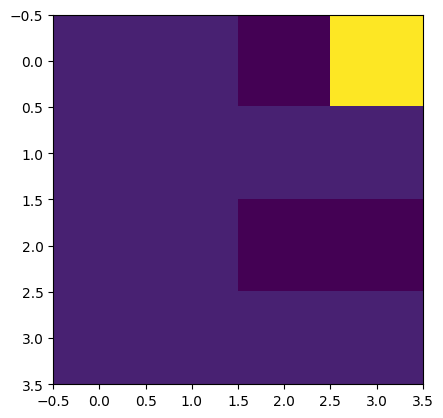

In [3]:
plt.imshow(rewards.reshape(4, 4))

## Load State Transition Table
Load the state transition table from a CSV file. This table defines the possible next states for each action in every state.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

## Define Q-Learning Update Function
Implement the Q-learning update rule, which updates Q-values for each state-action pair based on observed rewards and the estimated value of the next state.

In [5]:
def Q_update(next_Q_values, Q_values, actions, rewards, states):
    gamma = 0.99
    next_Q_values = next_Q_values
    new_Q_values = np.zeros((16,4)) + Q_values
    for i in reversed(range(len(rewards))):
        new_Q_values[states[i], actions[i]] = Q_values[states[i], actions[i]] + \
        alpha * (rewards[i] + gamma * next_Q_values - Q_values[states[i], actions[i]])
            
        next_Q_values = np.max(Q_values[states[i],:])
    return new_Q_values

## Define Agent Testing Function
Create a function to test the agent's current policy by running it from the start state to the terminal state, returning the total reward and the path taken.

In [ ]:
def test_agent():
    state = 12
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<100:
        states_log.append(state)
        action = np.argmax(Q_values[state])
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

## Train the Agent with Q-Learning and ε-Greedy Policy
Run multiple episodes where the agent explores the environment, collects rewards, and updates its Q-values using the Q-learning update rule. The ε-greedy policy balances exploration and exploitation.

In [7]:
for _ in range(1000):
    state = 12
    state_log = []
    reward_log = []
    action_log = []

    done = False
    steps = 0

    while (not(state == terminal_state)) and steps<30:
        z = random.random()
        if z >=epsilon:
            action = np.argmax(Q_values[state])
        else:
            action = random.randint(0,3)
        state_log.append(state)
        action_log.append(action)

        state = state_transition_table[state, action]
        reward_log.append(rewards[state])

        steps += 1

    next_Q_values = np.max(Q_values[state])
    Q_values = Q_update(next_Q_values, Q_values, action_log, reward_log, state_log)
    
    score_log.append(test_agent()[0])

## Visualize Learned Q-Values
Display the learned Q-values for each state-action pair after training. Each cell shows the estimated Q-value for that state and action.

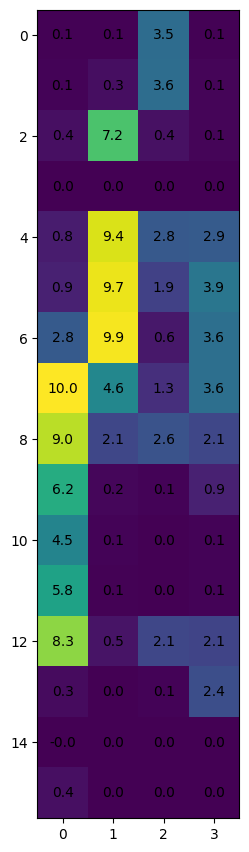

In [8]:
fig, ax1 = plt.subplots(1)
fig.set_size_inches(18.5, 10.5)
ax1.imshow(Q_values)

for (j,i), label in np.ndenumerate(Q_values.round(1)):
    ax1.text(i,j,label,ha='center',va='center')

## Plot Agent's Score Over Episodes
Visualize how the agent's total reward changes over training episodes to observe learning progress.

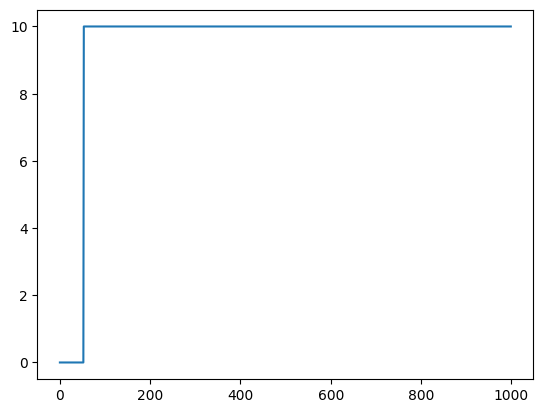

In [9]:
plt.plot(score_log)

## Visualize Agent's Final Path
Show the path taken by the trained agent from the start state to the terminal state, highlighting the states visited.

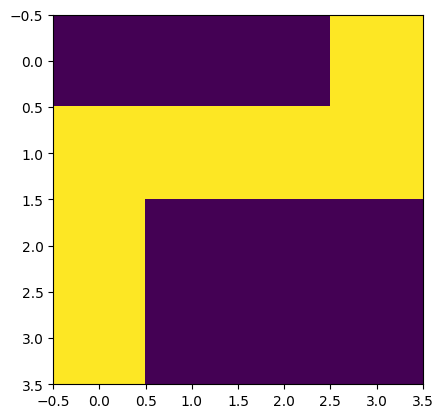

In [10]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))